# The code behind it: fit a regression line by hand

*Part 1 · Lesson 3 · the code behind it  ·  data: Ames housing (same as Lesson 3)*

*↩ A companion to [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb).*

**↩ Back:** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](03-relationships-regression~another-dataset.ipynb)

**In Lesson 3 you fit a regression line with library one-liners** — `area.corr(price)`,
`np.polyfit`, `stats.linregress`. They handed back a slope, an intercept and an `r` like magic words.
This companion **opens the hood**: you'll compute every one of those numbers *yourself*, straight from
the formulas, so a "least-squares line" stops being a function you call and becomes a handful of NumPy
lines you could write from memory.

Same Ames homes, same two variables (living `area` vs. sale `price`), same final numbers — but the focus
shifts from *what regression means* to **how you compute it in Python**. We'll go in the order a
programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load it, look at its shape, select columns, mask rows.
3. **Build it step by step** — turn the formulas for $r$, the slope, the intercept, the residuals and $R^2$ into NumPy, checking each against the library.
4. **The idiom** — the *vectorized* fitted-values-and-residuals line vs. a slow Python loop.
5. **Refactor into a function** — wrap it all up as your own reusable `fit_line()`.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 3 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written a function that takes two columns of numbers — a
predictor $x$ and a response $y$ — and returns the **slope**, **intercept**, **correlation $r$** and
**$R^2$** of the least-squares line through them: the exact same numbers `np.polyfit` and
`stats.linregress` hand you for free. Nothing here needs new statistics; everything is the Python
*underneath* the one-liners you already ran in Lesson 3.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **pandas** | tables (`DataFrame`) and columns (`Series`) | loading the CSV, selecting columns, masking rows |
| **NumPy** | fast math on whole arrays at once | the actual formulas (sum, sqrt, the fitted line) |
| **matplotlib** | plotting | the scatter-with-fit and the residual plot |

A **`DataFrame`** is a spreadsheet in code: named columns, numbered rows. A single column is a **`Series`** —
an array of values with an index. The whole regression below is "do some arithmetic to two Series at once."

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'   # same file + url as the core lesson
ames = sl.load_csv('ames.csv', url=AMES_URL)
print(f'Loaded a {type(ames).__name__} with shape {ames.shape}  (rows, columns)')

Loaded a DataFrame with shape (2930, 82)  (rows, columns)


## 2) The data in code

Before any statistics, a programmer *interrogates the object*: what type is it, how big is it, what are
the columns, what do the first rows look like? Four habits worth keeping:

- `.shape` → `(rows, columns)` as a tuple.
- `.columns` → the column names.
- `.dtypes` → the **type** of each column (`int64`/`float64` = numbers, `object` = text).
- `.head()` → the first few rows, to eyeball it.

In [2]:
print('shape  :', ames.shape)
print('the two columns we will study:', ['area', 'price'])
print('\ndtypes of those two columns:')
print(ames[['area', 'price']].dtypes)
ames[['area', 'price']].head()

shape  : (2930, 82)
the two columns we will study: ['area', 'price']

dtypes of those two columns:
area     int64
price    int64
dtype: object


,area,price
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900


### Selecting columns, masking rows, and missing values

- **One column** → `ames['area']` gives a `Series`.
- **A boolean mask** → `ames['area'] > 3000` makes a column of `True`/`False`; putting it *inside the
  brackets* keeps only the `True` rows. This is the single most useful pattern in pandas.

Real data has holes. A few homes are missing a measurement, stored as `NaN` ("not a number"). Math on a
`NaN` silently spreads it, so we drop the rows missing either column we need with `.dropna(subset=[...])`.
This makes a **new, smaller table** — it never edits the file on disk (our `raw/` data stays read-only).

In [3]:
print('rows missing area or price:', ames[['area', 'price']].isna().any(axis=1).sum())

ames = ames.dropna(subset=['area', 'price'])
print('rows kept after dropna     :', len(ames))

# Pull out the two columns we'll regress. Each is a Series of 2,930 numbers.
x = ames['area']      # predictor: above-grade living area (sq ft)
y = ames['price']     # response : sale price (dollars)
print('\nx is a', type(x).__name__, 'of', len(x), 'values; first 5 areas :', x.head().to_list())
print('y is a', type(y).__name__, 'of', len(y), 'values; first 5 prices:', y.head().to_list())

# A boolean mask in action: just the big homes.
big_mask = x > 3000
print(f'\nHomes over 3,000 sq ft: {big_mask.sum()} of {len(ames)}')

rows missing area or price: 0
rows kept after dropna     : 2930

x is a Series of 2930 values; first 5 areas : [1656, 896, 1329, 2110, 1629]
y is a Series of 2930 values; first 5 prices: [215000, 105000, 172000, 244000, 189900]

Homes over 3,000 sq ft: 26 of 2930


## 3) Build it step by step

Now the heart of it. Each piece of the regression is a one-line library call *and* a short formula —
we'll write the formula in NumPy and check the two agree to the last decimal with `np.isclose`. Once
you've built it, the library is no longer a mystery box.

### Pearson's correlation r, from its formula

Lesson 3's `area.corr(price)` is **Pearson's $r$**. Its formula looks scary but is just "do the
deviations of $x$ and $y$ move together?", scaled to land between $-1$ and $+1$:

$$r = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum (x_i-\bar{x})^2}\;\sqrt{\sum (y_i-\bar{y})^2}}.$$

Every $\sum$ is a `.sum()` over a vectorized product. The deviations `dx`, `dy` are computed for the
**whole column at once** — no loop. Build it and check against the one-liner.

In [4]:
dx = x - x.mean()      # every home's area minus the mean area, all at once
dy = y - y.mean()      # every home's price minus the mean price

r_by_hand = (dx * dy).sum() / np.sqrt((dx**2).sum() * (dy**2).sum())
r_pandas  = x.corr(y)

print(f'r by hand     : {r_by_hand:.6f}')
print(f'x.corr(y)     : {r_pandas:.6f}')
print('match?', np.isclose(r_by_hand, r_pandas))

r = r_by_hand
print(f'\n-> r = {r:.2f}: a strong, positive linear trend — bigger homes really do go with bigger prices.')

r by hand     : 0.706780
x.corr(y)     : 0.706780
match? True

-> r = 0.71: a strong, positive linear trend — bigger homes really do go with bigger prices.


### The slope — two formulas that must agree

The least-squares **slope** can be written two ways that are algebraically identical, so they had
better produce the same number:

$$b = r\,\frac{s_y}{s_x} \qquad\text{and}\qquad b = \frac{\operatorname{cov}(x,y)}{\operatorname{var}(x)}.$$

The first rescales the correlation from "per SD" back into real units (dollars per sq ft). The second
is the covariance of $x$ and $y$ over the variance of $x$. As long as we compute the SDs, the
covariance and the variance with the **same `ddof`**, the `1/(n-1)` factors cancel and the two agree.

In [5]:
n = len(x)
sx, sy = x.std(ddof=1), y.std(ddof=1)         # sample SDs (divide by n-1)
cov_xy = (dx * dy).sum() / (n - 1)            # sample covariance, same ddof=1
var_x  = (dx**2).sum()  / (n - 1)             # sample variance of x,   same ddof=1

slope_a = r * (sy / sx)                       # way 1: r * (s_y / s_x)
slope_b = cov_xy / var_x                      # way 2: cov(x, y) / var(x)

print(f'slope via r*(sy/sx)     : {slope_a:.6f}')
print(f'slope via cov(x,y)/var(x): {slope_b:.6f}')
print('match?', np.isclose(slope_a, slope_b))

b1 = slope_a
print(f'\n-> slope b1 = {b1:.2f}: each extra square foot is associated with about ${b1:.0f} more in price.')

slope via r*(sy/sx)     : 111.694001
slope via cov(x,y)/var(x): 111.694001
match? True

-> slope b1 = 111.69: each extra square foot is associated with about $112 more in price.


### The intercept, and the fitted line

The **intercept** comes straight from the requirement that the line pass through the point of averages
$(\bar{x}, \bar{y})$:

$$a = \bar{y} - b\,\bar{x}.$$

With the slope $b$ and intercept $a$ in hand, the **fitted (predicted) value** for every home is one
vectorized expression over the whole column:

$$\hat{y} = a + b\,x.$$

In [6]:
a = y.mean() - b1 * x.mean()
print(f'intercept a = {a:,.2f} dollars  (the predicted price of a 0-sq-ft "home" — not physically meaningful)')

yhat = a + b1 * x            # 2,930 predicted prices, computed in one line
print(f'\nyhat is a {type(yhat).__name__} of {len(yhat)} predictions; first 5:')
print(np.round(yhat.head().to_numpy(), 0))

intercept a = 13,289.63 dollars  (the predicted price of a 0-sq-ft "home" — not physically meaningful)

yhat is a Series of 2930 predictions; first 5:
[198255. 113367. 161731. 248964. 195239.]


### Residuals — what the line *misses*

The **residual** for each home is the leftover the line didn't catch — actual minus predicted:

$$e_i = y_i - \hat{y}_i.$$

A positive residual means the home sold for **more** than the line predicted; negative means **less**.
Like the fitted values, the whole column of residuals is one vectorized subtraction. A useful sanity
check: for a least-squares fit the residuals always **average to ~0**.

In [7]:
e = y - yhat                 # residuals for all 2,930 homes, one line
print(f'first 5 residuals (dollars): {np.round(e.head().to_numpy(), 0)}')
print(f'mean residual (should be ~0): {e.mean():.4f} dollars')

first 5 residuals (dollars): [16745. -8367. 10269. -4964. -5339.]
mean residual (should be ~0): -0.0000 dollars


### R² — two ways that must agree

How *good* is the fit, in one number? The **coefficient of determination** $R^2$ is the share of the
up-and-down variation in $y$ that the line accounts for. For a simple one-predictor regression there's
a beautiful shortcut — it's just the correlation squared — *and* it equals one minus the leftover
variation over the total variation. Both must give the same number:

$$R^2 = r^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}},\qquad
SS_{\text{res}}=\sum e_i^2,\quad SS_{\text{tot}}=\sum (y_i-\bar{y})^2.$$

In [8]:
ss_res = (e**2).sum()                 # leftover variation around the line
ss_tot = ((y - y.mean())**2).sum()    # total variation around the mean
R2_sums = 1 - ss_res / ss_tot         # way 1: from the sums of squares
R2_rsq  = r**2                        # way 2: just r, squared

print(f'R^2 from 1 - SS_res/SS_tot : {R2_sums:.6f}')
print(f'R^2 from r**2              : {R2_rsq:.6f}')
print('match?', np.isclose(R2_sums, R2_rsq))
print(f'\n-> About {R2_sums*100:.0f}% of the variation in sale price is explained by living area alone.')

R^2 from 1 - SS_res/SS_tot : 0.499538
R^2 from r**2              : 0.499538
match? True

-> About 50% of the variation in sale price is explained by living area alone.


### The final check: against `np.polyfit`

We built the slope and intercept from scratch. The library's `np.polyfit(x, y, 1)` fits the same line
by least squares and returns `[slope, intercept]`. If our formulas are right, the two must match to many
decimals — *that's the whole point*: the formula **is** what the library computes.

In [9]:
xn = x.to_numpy()
yn = y.to_numpy()
b1_np, a_np = np.polyfit(xn, yn, 1)      # returns [slope, intercept]

print(f'our slope     : {b1:.6f}      np.polyfit slope    : {b1_np:.6f}')
print(f'our intercept : {a:,.4f}   np.polyfit intercept: {a_np:,.4f}')
print('slope match?    ', np.isclose(b1, b1_np))
print('intercept match?', np.isclose(a, a_np))

our slope     : 111.694001      np.polyfit slope    : 111.694001
our intercept : 13,289.6344   np.polyfit intercept: 13,289.6344
slope match?     True
intercept match? True


### Draw it — the fit, and the residual plot

Two pictures finish the job. First the **scatter with our fitted line overlaid**: plot the dots, then
draw a straight segment from the smallest to the largest $x$ using *our own* `a` and `b1`. Second the
**residual plot** — residuals against $x$, with a horizontal line at zero. What you *want* to see is a
shapeless band around 0; a curve or a funnel would warn that a straight line is the wrong model.

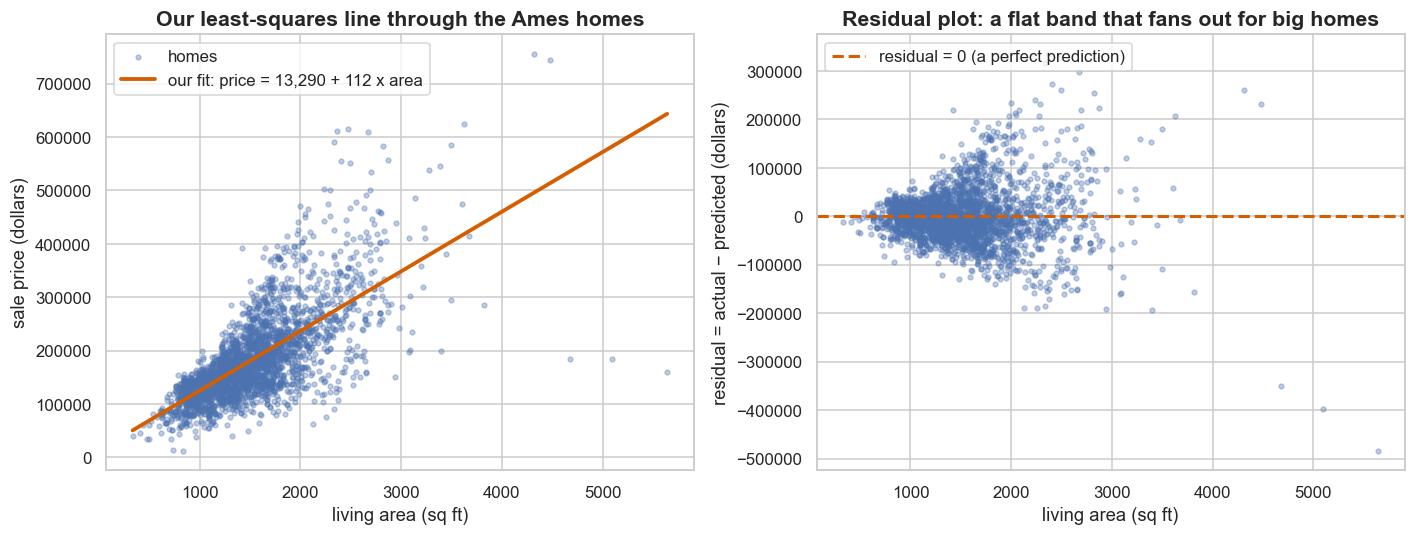

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.0))

# LEFT: scatter + our fitted line.
line_x = np.array([xn.min(), xn.max()])
line_y = a + b1 * line_x                  # our own intercept & slope
axL.scatter(xn, yn, s=10, alpha=0.35, color='#4c72b0', label='homes')
axL.plot(line_x, line_y, color='#D55E00', lw=2.5,
         label=f'our fit: price = {a:,.0f} + {b1:.0f} x area')
axL.set_xlabel('living area (sq ft)'); axL.set_ylabel('sale price (dollars)')
axL.set_title('Our least-squares line through the Ames homes')
axL.legend(loc='upper left')

# RIGHT: residuals vs x, with a zero line.
axR.scatter(xn, e.to_numpy(), s=10, alpha=0.35, color='#4c72b0')
axR.axhline(0, color='#D55E00', lw=2, ls='--', label='residual = 0 (a perfect prediction)')
axR.set_xlabel('living area (sq ft)'); axR.set_ylabel('residual = actual − predicted (dollars)')
axR.set_title('Residual plot: a flat band that fans out for big homes')
axR.legend(loc='upper left')

plt.tight_layout(); plt.show()

## 4) The idiom — vectorized vs. a loop

We computed all 2,930 residuals with **one expression**, `y - (a + b1 * x)`, because pandas/NumPy do
arithmetic on a whole column at once. You *could* instead loop over the homes one by one — it gives the
same numbers but is slower and noisier to read. Compare the two; the vectorized one-liner is the idiom
you want.

In [11]:
# The loop way (how you might first think of it):
resid_loop = []
for xi, yi in zip(xn, yn):
    resid_loop.append(yi - (a + b1 * xi))
resid_loop = np.array(resid_loop)

# The vectorized way (what NumPy/pandas is for) — the whole column at once:
resid_vec = yn - (a + b1 * xn)

print('same residuals either way?', np.allclose(resid_loop, resid_vec))
print(f'first 3, loop      : {np.round(resid_loop[:3], 1)}')
print(f'first 3, vectorized: {np.round(resid_vec[:3], 1)}')
print('\nThe vectorized line reads cleaner and runs far faster on big data — and it is what the')
print('library does under the hood. (`np.polyfit`/`stats.linregress` solve the same least-squares')
print('problem for you; here we did it by hand to see exactly what they return.)')

same residuals either way? True
first 3, loop      : [16745.1 -8367.5 10269. ]
first 3, vectorized: [16745.1 -8367.5 10269. ]

The vectorized line reads cleaner and runs far faster on big data — and it is what the
library does under the hood. (`np.polyfit`/`stats.linregress` solve the same least-squares
problem for you; here we did it by hand to see exactly what they return.)


## 5) Refactor into a reusable function

You've now written the same handful of lines (deviations, $r$, slope, intercept, $R^2$) once. The
programmer's reflex is to **wrap repeated work in a function**: name it, give it inputs, `return` the
result. Then "fit a line" is one call you can reuse on *any* pair of numeric columns — area vs. price, a
different predictor, a different dataset entirely.

In [12]:
def fit_line(x, y):
    '''Least-squares fit of y on x. Returns dict(slope, intercept, r, r2).'''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    dx = x - x.mean()
    dy = y - y.mean()
    r = (dx * dy).sum() / np.sqrt((dx**2).sum() * (dy**2).sum())
    slope = (dx * dy).sum() / (dx**2).sum()      # = cov(x,y)/var(x); the ddof cancels
    intercept = y.mean() - slope * x.mean()
    return {'slope': slope, 'intercept': intercept, 'r': r, 'r2': r**2}

# Reuse it on our two columns — and confirm it reproduces the by-hand numbers:
result = fit_line(ames['area'], ames['price'])
print('fit_line(area, price):')
for k, v in result.items():
    print(f'  {k:9}: {v:,.6f}')

print('\nmatches our step-by-step work?',
      np.isclose(result['slope'], b1),
      np.isclose(result['intercept'], a),
      np.isclose(result['r'], r),
      np.isclose(result['r2'], R2_sums))
print('\nCaution: a strong fit (high r, high R^2) shows association, NOT causation —')
print('bigger homes are *associated with* higher prices; the line alone never proves size *causes* price.')

fit_line(area, price):
  slope    : 111.694001
  intercept: 13,289.634365
  r        : 0.706780
  r2       : 0.499538

matches our step-by-step work? True True True True

Caution: a strong fit (high r, high R^2) shows association, NOT causation —
bigger homes are *associated with* higher prices; the line alone never proves size *causes* price.


A function is a contract: *give me two columns, I'll give you a dict with the slope, intercept, $r$ and
$R^2$.* Once it's correct, you stop thinking about the formulas and start thinking in **fits and
predictions** — exactly the leap from "writing statistics" to "doing statistics in code." (And yes,
`np.polyfit` and `stats.linregress` exist; the point was to *build* it so you know what they're doing.)

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the
answer before you run it.

1. **Predict a price.** Using your `a` and `b1`, write one line that predicts the price of a 2,000-sq-ft
   home: `a + b1 * 2000`. Is 2,000 inside the observed area range (the data spans 334 to 5,642 sq ft, so
   yes)? Now try `a + b1 * 50` — a 50-sq-ft "home." The line still hands back a number, but you're
   **extrapolating** far outside the data, so don't trust it.

2. **Residuals sum to zero — prove it.** Compute `e.sum()` and `e.mean()` for the residuals. They should
   be essentially 0 (a tiny floating-point dusting like `1e-7`). Why? Because the intercept formula
   $a=\bar{y}-b\bar{x}$ forces the line through the point of averages.

3. **Refit on a different predictor.** The Ames table has many columns (`ames.columns` lists them). Pick
   another numeric one — for example overall quality `'Overall.Qual'` — drop NaNs in it and `price`, then
   call `fit_line(...)` on it. Is its $r$ higher or lower than area's $\approx 0.71$?

4. **Check your function against the library.** Call `np.polyfit(ames['area'], ames['price'], 1)` and
   compare its `[slope, intercept]` to your `fit_line(...)` result with `np.isclose`. They should agree
   to many decimals — confirming your from-scratch fit *is* the least-squares fit.

## What you learned

**Coding**
- A `DataFrame` is a table; a column is a `Series`. Interrogate any new data with `.shape`, `.columns`,
  `.dtypes`, `.head()`, and filter rows with **boolean masks** (`df[df['col'] > value]`).
- **Vectorization** — arithmetic on whole columns at once (`x - x.mean()`, `a + b1 * x`, `y - yhat`) —
  computes all 2,930 fitted values and residuals in one expression, with no loop, and runs far faster.
- The same answer can be reached two ways that must agree (slope via `r*(sy/sx)` *and* `cov/var`; $R^2$
  via `r**2` *and* `1 - SS_res/SS_tot`) — a free correctness check with `np.isclose`.
- **Refactor repeated work into a function** with clear inputs and a `return` (here a dict), then reuse
  it on any pair of columns.

**Statistics (now demystified)**
- Pearson's `r`, the least-squares **slope** $b=r\,s_y/s_x=\operatorname{cov}/\operatorname{var}$, the
  **intercept** $a=\bar{y}-b\bar{x}$, the **residuals** $e=y-\hat{y}$, and **$R^2=r^2$** are each just a
  short formula; you reproduced every library number to the decimal and checked them against `np.polyfit`.
- For a least-squares fit the residuals average to ~0, and $R^2$ is the share of $y$'s variation the line
  explains. A high $r$ is **association, not causation**.

**Back to the core lesson** ([Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](03-relationships-regression~another-dataset.ipynb)